In [2]:
# =========================================================
# PHASE 1.1 — INSTALL DEPENDENCIES
# =========================================================

print("Installing libraries...")

!pip -q install datasets
!pip -q install sentence-transformers
!pip -q install faiss-cpu
!pip -q install pandas
!pip -q install numpy
!pip -q install scikit-learn
!pip -q install tqdm

print("Libraries installed successfully")

Installing libraries...
Libraries installed successfully


In [3]:
# =========================================================
# PHASE 1.2 — IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import faiss
import re

from tqdm import tqdm
from datasets import load_dataset
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer


# =========================================================
# SYSTEM CONFIGURATION
# =========================================================

CONFIG = {

    "MAX_QUERIES": 5000,

    "EMBEDDING_MODEL": "all-MiniLM-L6-v2",

    "EMBEDDING_DIM": 384,

    "INDEX_FILE": "sentinel_index.faiss",

    "DATA_FILE": "sentinel_queries.csv"

}

print("Configuration loaded:")
print(CONFIG)

Configuration loaded:
{'MAX_QUERIES': 5000, 'EMBEDDING_MODEL': 'all-MiniLM-L6-v2', 'EMBEDDING_DIM': 384, 'INDEX_FILE': 'sentinel_index.faiss', 'DATA_FILE': 'sentinel_queries.csv'}


In [6]:
# =========================================================
# PHASE 1.3 — DATASET LOADING (VERIFIED WORKING)
# =========================================================

from datasets import load_dataset

print("Downloading SQuAD dataset...")

dataset = load_dataset("squad")

print("Dataset downloaded successfully")

print("\nDataset structure:")
print(dataset)

print("\nExample record:")

sample = dataset["train"][0]

for key, value in sample.items():
    print(f"{key} : {value}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Dataset downloaded successfully

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

Example record:
id : 5733be284776f41900661182
title : University_of_Notre_Dame
context : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a dire

In [7]:
# =========================================================
# PHASE 1.4 — QUERY EXTRACTION + DATA CLEANING
# =========================================================

import re
import numpy as np
import pandas as pd
from tqdm import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

PHASE1_CONFIG = {

    "MAX_QUERIES": 30000,

    "MIN_QUERY_LENGTH": 5,

    "SAVE_FILE": "sentinel_queries.csv",

    "STATS_FILE": "dataset_stats.csv"

}

print("Configuration Loaded")
print(PHASE1_CONFIG)


# =========================================================
# STEP 1 — EXTRACT QUESTIONS FROM DATASET
# =========================================================

print("\nExtracting questions from dataset...")

queries = []

for row in dataset["train"]:

    q = row["question"]

    if q is None:
        continue

    if len(q) < PHASE1_CONFIG["MIN_QUERY_LENGTH"]:
        continue

    queries.append(q)

    if len(queries) >= PHASE1_CONFIG["MAX_QUERIES"]:
        break


print("Total queries collected:", len(queries))


# =========================================================
# STEP 2 — TEXT CLEANING FUNCTION
# =========================================================

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text


# =========================================================
# STEP 3 — CLEAN ALL QUERIES
# =========================================================

print("\nCleaning queries...")

clean_queries = []

for q in tqdm(queries):

    cleaned = clean_text(q)

    clean_queries.append(cleaned)


print("Cleaning completed")


# =========================================================
# STEP 4 — REMOVE DUPLICATES
# =========================================================

print("\nRemoving duplicates...")

clean_queries = list(set(clean_queries))

print("Queries after deduplication:", len(clean_queries))


# =========================================================
# STEP 5 — DATASET STATISTICS
# =========================================================

print("\nComputing dataset statistics...")

lengths = []

for q in clean_queries:

    lengths.append(len(q.split()))


stats = {

    "total_queries": len(clean_queries),

    "avg_query_length": float(np.mean(lengths)),

    "max_query_length": int(np.max(lengths)),

    "min_query_length": int(np.min(lengths))

}

print("\nDataset statistics:")
print(stats)


# =========================================================
# STEP 6 — SAVE STATISTICS
# =========================================================

stats_df = pd.DataFrame([stats])

stats_df.to_csv(

    PHASE1_CONFIG["STATS_FILE"],

    index=False

)

print("Statistics saved")


# =========================================================
# STEP 7 — SAVE CLEAN QUERY DATASET
# =========================================================

query_df = pd.DataFrame({

    "query": clean_queries

})

query_df.to_csv(

    PHASE1_CONFIG["SAVE_FILE"],

    index=False

)

print("Query dataset saved")


# =========================================================
# STEP 8 — SAMPLE OUTPUT
# =========================================================

print("\nSample cleaned queries:")

for q in clean_queries[:10]:

    print("-", q)


# =========================================================
# STEP 9 — QUERY LENGTH DISTRIBUTION
# =========================================================

print("\nAnalyzing query length distribution...")

length_counts = {}

for l in lengths:

    if l not in length_counts:
        length_counts[l] = 0

    length_counts[l] += 1


sorted_lengths = sorted(length_counts.items())

print("\nQuery Length Distribution (first 10):")

for item in sorted_lengths[:10]:

    print(item)


# =========================================================
# STEP 10 — DATA SUMMARY
# =========================================================

print("\n======================================")
print("PHASE 1.4 COMPLETED")
print("Clean queries prepared")
print("Dataset statistics generated")
print("Queries ready for embeddings")
print("======================================")

Configuration Loaded
{'MAX_QUERIES': 30000, 'MIN_QUERY_LENGTH': 5, 'SAVE_FILE': 'sentinel_queries.csv', 'STATS_FILE': 'dataset_stats.csv'}

Extracting questions from dataset...
Total queries collected: 30000

Cleaning queries...


100%|██████████| 30000/30000 [00:00<00:00, 122568.31it/s]


Cleaning completed

Removing duplicates...
Queries after deduplication: 29900

Computing dataset statistics...

Dataset statistics:
{'total_queries': 29900, 'avg_query_length': 10.324080267558529, 'max_query_length': 37, 'min_query_length': 2}
Statistics saved
Query dataset saved

Sample cleaned queries:
- what were the jews described as enemies of
- how many people auditioned to be on american idol
- what was bells discipline
- members of what commission criticized the separation of race and ethnic city on the us census
- who wrote the sarvadaranasamgraha
- what compression did the first european hdtv broadcast use
- who declared the mourning period
- what objects are notably bright in near ir
- in 1995 who decided to manage the girls singing group
- what other successful theme restaurant chain was planet hollywood modeled on

Analyzing query length distribution...

Query Length Distribution (first 10):
(2, 1)
(3, 78)
(4, 424)
(5, 1156)
(6, 1920)
(7, 2909)
(8, 3654)
(9, 3702)
(10, 351

In [8]:
# =========================================================
# PHASE 1.5 — EMBEDDING ENGINE + VECTOR DATABASE
# =========================================================

import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from tqdm import tqdm
import os


# =========================================================
# CONFIGURATION
# =========================================================

EMBED_CONFIG = {

    "EMBED_MODEL": "all-MiniLM-L6-v2",

    "BATCH_SIZE": 64,

    "VECTOR_DIM": 384,

    "FAISS_FILE": "sentinel_vector.index",

    "EMBED_FILE": "query_embeddings.npy"

}

print("Embedding configuration loaded")
print(EMBED_CONFIG)


# =========================================================
# STEP 1 — LOAD QUERY DATASET
# =========================================================

print("\nLoading query dataset...")

query_df = pd.read_csv("sentinel_queries.csv")

queries = query_df["query"].tolist()

print("Total queries loaded:", len(queries))


# =========================================================
# STEP 2 — LOAD EMBEDDING MODEL
# =========================================================

print("\nLoading embedding model...")

model = SentenceTransformer(EMBED_CONFIG["EMBED_MODEL"])

print("Embedding model loaded")


# =========================================================
# STEP 3 — GENERATE EMBEDDINGS
# =========================================================

print("\nGenerating embeddings...")

embeddings = model.encode(

    queries,

    batch_size=EMBED_CONFIG["BATCH_SIZE"],

    show_progress_bar=True

)

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)


# =========================================================
# STEP 4 — NORMALIZE VECTORS
# =========================================================

print("\nNormalizing embeddings...")

embeddings = normalize(embeddings)

print("Normalization completed")


# =========================================================
# STEP 5 — BUILD FAISS VECTOR DATABASE
# =========================================================

print("\nBuilding FAISS vector index...")

dimension = EMBED_CONFIG["VECTOR_DIM"]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("Vectors stored in index:", index.ntotal)


# =========================================================
# STEP 6 — TEST VECTOR SEARCH
# =========================================================

def search_similar(query, top_k=5):

    q_vec = model.encode([query])

    q_vec = normalize(q_vec)

    scores, ids = index.search(q_vec, top_k)

    results = []

    for i in ids[0]:

        results.append(queries[i])

    return results


print("\nTesting semantic search...")

test_query = "how does machine learning work"

results = search_similar(test_query)

print("\nQuery:", test_query)

print("\nSimilar queries:")

for r in results:

    print("-", r)


# =========================================================
# STEP 7 — CLUSTER QUERIES
# =========================================================

print("\nClustering query embeddings...")

num_clusters = 10

kmeans = KMeans(

    n_clusters=num_clusters,

    random_state=42

)

cluster_labels = kmeans.fit_predict(embeddings)

print("Clustering completed")


# =========================================================
# STEP 8 — ANALYZE CLUSTERS
# =========================================================

cluster_counts = {}

for c in cluster_labels:

    if c not in cluster_counts:
        cluster_counts[c] = 0

    cluster_counts[c] += 1


print("\nCluster distribution:")

for k, v in cluster_counts.items():

    print("Cluster", k, ":", v)


# =========================================================
# STEP 9 — SAVE EMBEDDINGS
# =========================================================

print("\nSaving embeddings...")

np.save(

    EMBED_CONFIG["EMBED_FILE"],

    embeddings

)

print("Embeddings saved")


# =========================================================
# STEP 10 — SAVE VECTOR INDEX
# =========================================================

print("\nSaving FAISS index...")

faiss.write_index(

    index,

    EMBED_CONFIG["FAISS_FILE"]

)

print("Vector index saved")


# =========================================================
# STEP 11 — SAVE CLUSTER DATA
# =========================================================

cluster_df = pd.DataFrame({

    "query": queries,

    "cluster": cluster_labels

})

cluster_df.to_csv(

    "query_clusters.csv",

    index=False

)

print("Cluster data saved")


# =========================================================
# STEP 12 — SYSTEM SUMMARY
# =========================================================

print("\n===================================")
print("PHASE 1 COMPLETED SUCCESSFULLY")
print("Vector database ready")
print("Embeddings generated")
print("Queries clustered")
print("===================================")

Embedding configuration loaded
{'EMBED_MODEL': 'all-MiniLM-L6-v2', 'BATCH_SIZE': 64, 'VECTOR_DIM': 384, 'FAISS_FILE': 'sentinel_vector.index', 'EMBED_FILE': 'query_embeddings.npy'}

Loading query dataset...
Total queries loaded: 29900

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded

Generating embeddings...


Batches:   0%|          | 0/468 [00:00<?, ?it/s]

Embedding shape: (29900, 384)

Normalizing embeddings...
Normalization completed

Building FAISS vector index...
Vectors stored in index: 29900

Testing semantic search...

Query: how does machine learning work

Similar queries:
- how is information sent through a simple model
- computer programs that can learn are studied in what field
- what is the project called that is trying to build a realistic detailed computer model of the human brain
- perceiving information and retaining it is what
- why was this classification made

Clustering query embeddings...
Clustering completed

Cluster distribution:
Cluster 4 : 4813
Cluster 7 : 2404
Cluster 6 : 3217
Cluster 0 : 2999
Cluster 2 : 3648
Cluster 8 : 3632
Cluster 9 : 3076
Cluster 3 : 2711
Cluster 1 : 2886
Cluster 5 : 514

Saving embeddings...
Embeddings saved

Saving FAISS index...
Vector index saved
Cluster data saved

PHASE 1 COMPLETED SUCCESSFULLY
Vector database ready
Embeddings generated
Queries clustered


In [9]:
# =========================================================
# PHASE 2.1 — QUERY COMPLEXITY ANALYZER
# =========================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA


# =========================================================
# CONFIGURATION
# =========================================================

ROUTER_CONFIG = {

    "EMBED_FILE": "query_embeddings.npy",

    "QUERY_FILE": "sentinel_queries.csv",

    "FEATURE_FILE": "router_features.csv",

    "PCA_DIM": 10

}

print("Router configuration loaded")
print(ROUTER_CONFIG)


# =========================================================
# STEP 1 — LOAD DATA
# =========================================================

print("\nLoading query dataset...")

query_df = pd.read_csv(ROUTER_CONFIG["QUERY_FILE"])

queries = query_df["query"].tolist()

print("Queries loaded:", len(queries))


print("\nLoading embeddings...")

embeddings = np.load(ROUTER_CONFIG["EMBED_FILE"])

print("Embedding shape:", embeddings.shape)


# =========================================================
# STEP 2 — COMPUTE QUERY LENGTH
# =========================================================

print("\nComputing query length features...")

query_lengths = []

for q in queries:

    tokens = q.split()

    query_lengths.append(len(tokens))

query_lengths = np.array(query_lengths)

print("Average query length:", np.mean(query_lengths))


# =========================================================
# STEP 3 — WORD COMPLEXITY
# =========================================================

print("\nComputing word complexity...")

unique_words = []

for q in queries:

    words = set(q.split())

    unique_words.append(len(words))

unique_words = np.array(unique_words)


# =========================================================
# STEP 4 — EMBEDDING MAGNITUDE
# =========================================================

print("\nComputing embedding magnitudes...")

magnitudes = np.linalg.norm(

    embeddings,

    axis=1

)


# =========================================================
# STEP 5 — PCA SEMANTIC COMPLEXITY
# =========================================================

print("\nComputing semantic complexity using PCA...")

pca = PCA(

    n_components=ROUTER_CONFIG["PCA_DIM"]

)

pca_features = pca.fit_transform(embeddings)

print("PCA features shape:", pca_features.shape)


# =========================================================
# STEP 6 — NORMALIZE FEATURES
# =========================================================

print("\nNormalizing features...")

scaler = MinMaxScaler()

length_scaled = scaler.fit_transform(

    query_lengths.reshape(-1,1)

)

unique_scaled = scaler.fit_transform(

    unique_words.reshape(-1,1)

)

mag_scaled = scaler.fit_transform(

    magnitudes.reshape(-1,1)

)


# =========================================================
# STEP 7 — BUILD FEATURE MATRIX
# =========================================================

print("\nBuilding router feature matrix...")

features = np.hstack([

    length_scaled,

    unique_scaled,

    mag_scaled,

    pca_features

])

print("Feature matrix shape:", features.shape)


# =========================================================
# STEP 8 — ESTIMATE QUERY DIFFICULTY
# =========================================================

print("\nEstimating difficulty scores...")

difficulty = (

    length_scaled.flatten() * 0.4 +

    unique_scaled.flatten() * 0.3 +

    mag_scaled.flatten() * 0.3

)


# =========================================================
# STEP 9 — CREATE DIFFICULTY LABELS
# =========================================================

labels = []

for d in difficulty:

    if d < 0.33:

        labels.append("easy")

    elif d < 0.66:

        labels.append("medium")

    else:

        labels.append("hard")


print("\nDifficulty distribution:")

from collections import Counter

print(Counter(labels))


# =========================================================
# STEP 10 — SAVE ROUTER DATASET
# =========================================================

router_df = pd.DataFrame(features)

router_df["difficulty"] = labels

router_df.to_csv(

    ROUTER_CONFIG["FEATURE_FILE"],

    index=False

)

print("\nRouter feature dataset saved")


# =========================================================
# STEP 11 — SAMPLE OUTPUT
# =========================================================

print("\nSample router rows:")

print(router_df.head())


# =========================================================
# SUMMARY
# =========================================================

print("\n================================")
print("PHASE 2.1 COMPLETED")
print("Query complexity features built")
print("Difficulty labels created")
print("Router training data ready")
print("================================")

Router configuration loaded
{'EMBED_FILE': 'query_embeddings.npy', 'QUERY_FILE': 'sentinel_queries.csv', 'FEATURE_FILE': 'router_features.csv', 'PCA_DIM': 10}

Loading query dataset...
Queries loaded: 29900

Loading embeddings...
Embedding shape: (29900, 384)

Computing query length features...
Average query length: 10.324080267558529

Computing word complexity...

Computing embedding magnitudes...

Computing semantic complexity using PCA...
PCA features shape: (29900, 10)

Normalizing features...

Building router feature matrix...
Feature matrix shape: (29900, 13)

Estimating difficulty scores...

Difficulty distribution:
Counter({'easy': 29138, 'medium': 761, 'hard': 1})

Router feature dataset saved

Sample router rows:
          0         1             2         3         4         5         6  \
0  0.171429  0.181818  2.384186e-07  0.233629  0.186281  0.123176  0.015295   
1  0.200000  0.212121  2.384186e-07 -0.297666 -0.068312  0.078803 -0.129137   
2  0.057143  0.060606  2.38418

In [11]:
# =========================================================
# STEP 6 — MODEL EVALUATION (FIXED VERSION)
# =========================================================

print("\nEvaluating model...")

y_pred = router_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Router accuracy:", accuracy)

print("\nClassification report:")

from sklearn.metrics import classification_report

labels_all = list(range(len(encoder.classes_)))

print(

    classification_report(

        y_test,
        y_pred,

        labels=labels_all,

        target_names=encoder.classes_,

        zero_division=0

    )

)


Evaluating model...
Router accuracy: 0.9996655518394649

Classification report:
              precision    recall  f1-score   support

        easy       1.00      1.00      1.00      5833
        hard       0.00      0.00      0.00         0
      medium       1.00      0.99      0.99       147

    accuracy                           1.00      5980
   macro avg       0.67      0.66      0.66      5980
weighted avg       1.00      1.00      1.00      5980



In [12]:
# =========================================================
# STEP 6 — MODEL EVALUATION (EXTENDED VERSION)
# =========================================================

print("\n=================================================")
print("STARTING ROUTER MODEL EVALUATION")
print("=================================================")


# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

print("\nGenerating predictions from router model...")

y_pred = router_model.predict(X_test)

print("Prediction generation complete")

print("Total predictions:", len(y_pred))


# ---------------------------------------------------------
# BASIC ACCURACY METRIC
# ---------------------------------------------------------

print("\nComputing accuracy score...")

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Router accuracy score:", accuracy)


# ---------------------------------------------------------
# ANALYZE LABEL DISTRIBUTION
# ---------------------------------------------------------

print("\nAnalyzing label distribution...")

from collections import Counter

true_distribution = Counter(y_test)

pred_distribution = Counter(y_pred)

print("\nTrue label distribution:")

for label, count in true_distribution.items():

    label_name = encoder.inverse_transform([label])[0]

    print(label_name, ":", count)


print("\nPredicted label distribution:")

for label, count in pred_distribution.items():

    label_name = encoder.inverse_transform([label])[0]

    print(label_name, ":", count)


# ---------------------------------------------------------
# PREPARE LABEL LIST
# ---------------------------------------------------------

print("\nPreparing label indices for evaluation...")

all_labels = list(range(len(encoder.classes_)))

print("Label indices:", all_labels)

print("Label names:")

for i, name in enumerate(encoder.classes_):

    print(i, "->", name)


# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nGenerating classification report...")

report = classification_report(

    y_test,

    y_pred,

    labels=all_labels,

    target_names=encoder.classes_,

    zero_division=0,

    digits=4

)

print("\n========================================")

print(report)

print("========================================")


# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

print("\nComputing confusion matrix...")

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=all_labels

)

print("\nConfusion Matrix:")

print(cm)


# ---------------------------------------------------------
# DETAILED CLASS ANALYSIS
# ---------------------------------------------------------

print("\nPerforming per-class performance analysis...")

num_classes = len(encoder.classes_)

for i in range(num_classes):

    class_name = encoder.classes_[i]

    true_count = true_distribution.get(i, 0)

    pred_count = pred_distribution.get(i, 0)

    print("\nClass:", class_name)

    print("True samples:", true_count)

    print("Predicted samples:", pred_count)


# ---------------------------------------------------------
# ERROR ANALYSIS
# ---------------------------------------------------------

print("\nRunning error analysis...")

errors = []

for i in range(len(y_test)):

    if y_test[i] != y_pred[i]:

        errors.append(i)


print("Total misclassified samples:", len(errors))


if len(errors) > 0:

    print("\nExample misclassification indices:")

    print(errors[:10])


# ---------------------------------------------------------
# FINAL EVALUATION SUMMARY
# ---------------------------------------------------------

print("\n=================================================")
print("ROUTER MODEL EVALUATION COMPLETE")
print("=================================================")

print("Accuracy:", accuracy)

print("Total test samples:", len(y_test))

print("Misclassified samples:", len(errors))

print("Evaluation finished successfully")


STARTING ROUTER MODEL EVALUATION

Generating predictions from router model...
Prediction generation complete
Total predictions: 5980

Computing accuracy score...
Router accuracy score: 0.9996655518394649

Analyzing label distribution...

True label distribution:
easy : 5833
medium : 147

Predicted label distribution:
easy : 5835
medium : 145

Preparing label indices for evaluation...
Label indices: [0, 1, 2]
Label names:
0 -> easy
1 -> hard
2 -> medium

Generating classification report...

              precision    recall  f1-score   support

        easy     0.9997    1.0000    0.9998      5833
        hard     0.0000    0.0000    0.0000         0
      medium     1.0000    0.9864    0.9932       147

    accuracy                         0.9997      5980
   macro avg     0.6666    0.6621    0.6643      5980
weighted avg     0.9997    0.9997    0.9997      5980


Computing confusion matrix...

Confusion Matrix:
[[5833    0    0]
 [   0    0    0]
 [   2    0  145]]

Performing per-cl

In [13]:
# =========================================================
# PHASE 2.2 — ROUTER MODEL TRAINING SYSTEM
# =========================================================

import numpy as np
import pandas as pd
import joblib
import os
import sys
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from collections import Counter


# =========================================================
# CONFIGURATION SECTION
# =========================================================

ROUTER_CONFIG = {

    "FEATURE_FILE": "router_features.csv",

    "MODEL_FILE": "sentinel_router.pkl",

    "TEST_SIZE": 0.2,

    "RANDOM_STATE": 42,

    "N_ESTIMATORS": 200,

    "MAX_DEPTH": 15

}

print("Router configuration loaded")
print(ROUTER_CONFIG)


# =========================================================
# STEP 1 — VERIFY DATA FILE
# =========================================================

print("\nChecking dataset file...")

if not os.path.exists(ROUTER_CONFIG["FEATURE_FILE"]):

    print("ERROR: router feature file not found")

    sys.exit()

print("Dataset file located")


# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

print("\nLoading router dataset...")

router_df = pd.read_csv(

    ROUTER_CONFIG["FEATURE_FILE"]

)

print("Dataset loaded successfully")

print("Dataset shape:", router_df.shape)

print("\nPreview rows")

print(router_df.head())


# =========================================================
# STEP 3 — BASIC DATASET STATS
# =========================================================

print("\nRunning dataset statistics")

num_rows = router_df.shape[0]

num_cols = router_df.shape[1]

print("Rows:", num_rows)

print("Columns:", num_cols)

print("Column names:")

for c in router_df.columns:

    print("-", c)


# =========================================================
# STEP 4 — FEATURE / LABEL SPLIT
# =========================================================

print("\nSplitting features and labels")

X = router_df.drop("difficulty", axis=1)

y = router_df["difficulty"]

print("Feature matrix shape:", X.shape)

print("Label vector size:", len(y))


# =========================================================
# STEP 5 — LABEL ENCODING
# =========================================================

print("\nEncoding labels")

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Label mapping")

for idx, name in enumerate(encoder.classes_):

    print(idx, "->", name)


# =========================================================
# STEP 6 — TRAIN TEST SPLIT
# =========================================================

print("\nCreating train/test split")

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=ROUTER_CONFIG["TEST_SIZE"],

    random_state=ROUTER_CONFIG["RANDOM_STATE"]

)

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))


# =========================================================
# STEP 7 — TRAIN ROUTER MODEL
# =========================================================

print("\nTraining RandomForest router")

router_model = RandomForestClassifier(

    n_estimators=ROUTER_CONFIG["N_ESTIMATORS"],

    max_depth=ROUTER_CONFIG["MAX_DEPTH"],

    random_state=ROUTER_CONFIG["RANDOM_STATE"],

    n_jobs=-1

)

start_time = time.time()

router_model.fit(

    X_train,

    y_train

)

end_time = time.time()

print("Training complete")

print("Training time:", end_time - start_time)


# =========================================================
# STEP 8 — GENERATE PREDICTIONS
# =========================================================

print("\nGenerating predictions")

y_pred = router_model.predict(

    X_test

)

print("Prediction complete")


# =========================================================
# STEP 9 — ACCURACY METRIC
# =========================================================

print("\nCalculating accuracy")

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Router accuracy:", accuracy)


# =========================================================
# STEP 10 — LABEL DISTRIBUTION
# =========================================================

print("\nAnalyzing label distributions")

true_dist = Counter(y_test)

pred_dist = Counter(y_pred)

print("\nTrue distribution")

for label, count in true_dist.items():

    name = encoder.inverse_transform([label])[0]

    print(name, ":", count)

print("\nPredicted distribution")

for label, count in pred_dist.items():

    name = encoder.inverse_transform([label])[0]

    print(name, ":", count)


# =========================================================
# STEP 11 — CLASSIFICATION REPORT
# =========================================================

print("\nGenerating classification report")

labels_all = list(

    range(len(encoder.classes_))

)

report = classification_report(

    y_test,

    y_pred,

    labels=labels_all,

    target_names=encoder.classes_,

    zero_division=0,

    digits=4

)

print(report)


# =========================================================
# STEP 12 — CONFUSION MATRIX
# =========================================================

print("\nComputing confusion matrix")

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=labels_all

)

print(cm)


# =========================================================
# STEP 13 — FEATURE IMPORTANCE
# =========================================================

print("\nAnalyzing feature importance")

importances = router_model.feature_importances_

feature_names = list(X.columns)

importance_pairs = []

for i in range(len(feature_names)):

    importance_pairs.append(

        (feature_names[i], importances[i])

    )

importance_pairs.sort(

    key=lambda x: x[1],

    reverse=True

)

print("\nTop important features")

for name, score in importance_pairs[:10]:

    print(name, ":", score)


# =========================================================
# STEP 14 — SAVE ROUTER MODEL
# =========================================================

print("\nSaving router model")

joblib.dump(

    {

        "model": router_model,

        "encoder": encoder

    },

    ROUTER_CONFIG["MODEL_FILE"]

)

print("Model saved")


# =========================================================
# STEP 15 — ROUTING FUNCTION
# =========================================================

def route_query(feature_vector):

    pred = router_model.predict(

        [feature_vector]

    )[0]

    difficulty = encoder.inverse_transform(

        [pred]

    )[0]

    if difficulty == "easy":

        model = "Phi-3 Mini"

    else:

        model = "Mistral-7B-Instruct"

    return difficulty, model


print("\nRouter function ready")


# =========================================================
# STEP 16 — TEST ROUTER
# =========================================================

print("\nTesting router with sample feature")

sample_vector = X_test.iloc[0].values

diff, model = route_query(sample_vector)

print("Predicted difficulty:", diff)

print("Selected model:", model)


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n========================================")
print("PHASE 2.2 COMPLETED SUCCESSFULLY")
print("Router model trained")
print("Evaluation completed")
print("Model saved")
print("========================================")

Router configuration loaded
{'FEATURE_FILE': 'router_features.csv', 'MODEL_FILE': 'sentinel_router.pkl', 'TEST_SIZE': 0.2, 'RANDOM_STATE': 42, 'N_ESTIMATORS': 200, 'MAX_DEPTH': 15}

Checking dataset file...
Dataset file located

Loading router dataset...
Dataset loaded successfully
Dataset shape: (29900, 14)

Preview rows
          0         1             2         3         4         5         6  \
0  0.171429  0.181818  2.384186e-07  0.233629  0.186281  0.123176  0.015295   
1  0.200000  0.212121  2.384186e-07 -0.297666 -0.068312  0.078803 -0.129137   
2  0.057143  0.060606  2.384186e-07  0.068529  0.030579  0.088304 -0.131357   
3  0.400000  0.363636  2.384186e-07 -0.069604  0.072459 -0.078824  0.102149   
4  0.057143  0.060606  3.576279e-07  0.188774  0.038745  0.210150 -0.032085   

          7         8         9        10        11        12 difficulty  
0 -0.122956 -0.111489 -0.034101 -0.020063 -0.053437 -0.036883       easy  
1 -0.141338 -0.180016 -0.144553 -0.312216 -0.007269

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
# =========================================================
# PHASE 2.3 — LLM ROUTING EXECUTION ENGINE
# =========================================================

import numpy as np
import pandas as pd
import joblib
import time
import os

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
import torch


# =========================================================
# CONFIGURATION
# =========================================================

ROUTER_MODEL_FILE = "sentinel_router.pkl"

QUERY_FILE = "sentinel_queries.csv"

ROUTING_OUTPUT_FILE = "routing_results.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


# =========================================================
# LOAD ROUTER MODEL
# =========================================================

print("\nLoading router model...")

router_data = joblib.load(

    ROUTER_MODEL_FILE

)

router_model = router_data["model"]

encoder = router_data["encoder"]

print("Router model loaded")


# =========================================================
# LOAD QUERY DATA
# =========================================================

print("\nLoading queries...")

query_df = pd.read_csv(

    QUERY_FILE

)

queries = query_df["query"].tolist()

print("Queries loaded:", len(queries))


# =========================================================
# LOAD FEATURE DATA
# =========================================================

print("\nLoading router features...")

feature_df = pd.read_csv(

    "router_features.csv"

)

features = feature_df.drop(

    "difficulty",

    axis=1

).values

print("Feature matrix shape:", features.shape)


# =========================================================
# LOAD SMALL MODEL
# =========================================================

print("\nLoading Phi-3 model...")

phi_model_name = "microsoft/phi-3-mini-4k-instruct"

phi_tokenizer = AutoTokenizer.from_pretrained(

    phi_model_name

)

phi_model = AutoModelForCausalLM.from_pretrained(

    phi_model_name,

    torch_dtype=torch.float16,

    device_map="auto"

)

print("Phi model loaded")


# =========================================================
# LOAD STRONG MODEL
# =========================================================

print("\nLoading Mistral model...")

mistral_model_name = "mistralai/Mistral-7B-Instruct-v0.2"

mistral_tokenizer = AutoTokenizer.from_pretrained(

    mistral_model_name

)

mistral_model = AutoModelForCausalLM.from_pretrained(

    mistral_model_name,

    torch_dtype=torch.float16,

    device_map="auto"

)

print("Mistral model loaded")



Device: cuda

Loading router model...
Router model loaded

Loading queries...
Queries loaded: 29900

Loading router features...
Feature matrix shape: (29900, 13)

Loading Phi-3 model...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Mistral model loaded

Running routing pipeline
Processed 0 queries


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Processed 20 queries


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 

In [16]:
# =========================================================
# PREPARE FEATURE COLUMN NAMES
# =========================================================

print("\nPreparing feature column names for router")

feature_columns = feature_df.drop(

    "difficulty",

    axis=1

).columns.tolist()

print("Total router features:", len(feature_columns))

print("Example features:")

for f in feature_columns[:10]:

    print("-", f)


Preparing feature column names for router
Total router features: 13
Example features:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
- 8
- 9


In [17]:
# =========================================================
# PREPARE FEATURE COLUMN NAMES
# =========================================================

print("\nPreparing feature column names")

feature_columns = feature_df.drop(
    "difficulty",
    axis=1
).columns.tolist()

print("Number of router features:", len(feature_columns))


# =========================================================
# ROUTER FUNCTION
# =========================================================

def route_query(feature_vector):

    feature_input = pd.DataFrame(
        [feature_vector],
        columns=feature_columns
    )

    pred = router_model.predict(
        feature_input
    )[0]

    difficulty = encoder.inverse_transform(
        [pred]
    )[0]

    if difficulty == "easy":

        model_name = "phi"

    elif difficulty == "medium":

        model_name = "mistral"

    else:

        model_name = "mistral"

    return difficulty, model_name


# =========================================================
# LLM RESPONSE GENERATOR
# =========================================================

def generate_response(prompt, model_type):

    if model_type == "phi":

        tokenizer = phi_tokenizer
        model = phi_model

    else:

        tokenizer = mistral_tokenizer
        model = mistral_model


    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)


    output = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )

    text = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    return text


# =========================================================
# LIMIT QUERIES FOR COLAB PERFORMANCE
# =========================================================

print("\nLimiting queries for safe execution")

queries = queries[:100]
features = features[:100]

print("Queries to process:", len(queries))


# =========================================================
# RUN ROUTING PIPELINE
# =========================================================

print("\n===================================")
print("RUNNING LLM ROUTING PIPELINE")
print("===================================")

results = []

total_queries = len(queries)

for i in range(total_queries):

    query = queries[i]

    feature_vector = features[i]


    # route query
    difficulty, model_type = route_query(
        feature_vector
    )


    # generate response
    answer = generate_response(
        query,
        model_type
    )


    results.append({

        "query": query,
        "difficulty": difficulty,
        "model_used": model_type,
        "answer": answer

    })


    if i % 10 == 0:

        print(
            "Processed",
            i,
            "/",
            total_queries,
            "queries"
        )


print("\nRouting completed")


# =========================================================
# SAVE RESULTS
# =========================================================

print("\nSaving routing results")

results_df = pd.DataFrame(results)

results_df.to_csv(
    ROUTING_OUTPUT_FILE,
    index=False
)

print("Results saved to:", ROUTING_OUTPUT_FILE)


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("PHASE 2.3 COMPLETED SUCCESSFULLY")
print("Router executed")
print("LLM responses generated")
print("Results dataset stored")
print("===================================")


Preparing feature column names
Number of router features: 13

Limiting queries for safe execution
Queries to process: 100

RUNNING LLM ROUTING PIPELINE
Processed 0 / 100 queries
Processed 10 / 100 queries
Processed 20 / 100 queries
Processed 30 / 100 queries
Processed 40 / 100 queries
Processed 50 / 100 queries
Processed 60 / 100 queries
Processed 70 / 100 queries
Processed 80 / 100 queries
Processed 90 / 100 queries

Routing completed

Saving routing results
Results saved to: routing_results.csv

PHASE 2.3 COMPLETED SUCCESSFULLY
Router executed
LLM responses generated
Results dataset stored


In [18]:
# =========================================================
# PHASE 2.4 — ROUTING ANALYTICS + COST OPTIMIZATION
# =========================================================

import pandas as pd
import numpy as np


# =========================================================
# CONFIGURATION
# =========================================================

ROUTING_RESULTS_FILE = "routing_results.csv"

ANALYTICS_OUTPUT_FILE = "routing_analytics.csv"


# Estimated cost per 1k tokens (simulation)
MODEL_COSTS = {

    "phi": 0.001,

    "mistral": 0.008

}

print("Cost configuration loaded")
print(MODEL_COSTS)


# =========================================================
# LOAD ROUTING RESULTS
# =========================================================

print("\nLoading routing results")

results_df = pd.read_csv(

    ROUTING_RESULTS_FILE

)

print("Dataset shape:", results_df.shape)

print(results_df.head())


# =========================================================
# BASIC ROUTING STATISTICS
# =========================================================

print("\nComputing routing statistics")

total_queries = len(results_df)

phi_queries = len(

    results_df[
        results_df["model_used"] == "phi"
    ]
)

mistral_queries = len(

    results_df[
        results_df["model_used"] == "mistral"
    ]
)

print("Total queries:", total_queries)
print("Phi queries:", phi_queries)
print("Mistral queries:", mistral_queries)


# =========================================================
# RESPONSE LENGTH ANALYSIS
# =========================================================

print("\nAnalyzing response lengths")

response_lengths = []

for text in results_df["answer"]:

    length = len(str(text).split())

    response_lengths.append(length)

results_df["response_length"] = response_lengths

print("Average response length:", np.mean(response_lengths))


# =========================================================
# ESTIMATE TOKEN USAGE
# =========================================================

print("\nEstimating token usage")

token_estimates = []

for text in results_df["answer"]:

    tokens = len(str(text).split()) * 1.3

    token_estimates.append(tokens)

results_df["estimated_tokens"] = token_estimates


# =========================================================
# COMPUTE COST PER QUERY
# =========================================================

print("\nComputing estimated costs")

costs = []

for i in range(len(results_df)):

    model = results_df.iloc[i]["model_used"]

    tokens = results_df.iloc[i]["estimated_tokens"]

    cost = (tokens / 1000) * MODEL_COSTS[model]

    costs.append(cost)

results_df["estimated_cost"] = costs


# =========================================================
# TOTAL COST ANALYSIS
# =========================================================

print("\nCost analysis")

total_cost = np.sum(costs)

avg_cost = np.mean(costs)

print("Total cost:", total_cost)

print("Average cost per query:", avg_cost)


# =========================================================
# BASELINE COST COMPARISON
# =========================================================

print("\nComparing with baseline (all queries → Mistral)")

baseline_cost = 0

for tokens in token_estimates:

    baseline_cost += (tokens / 1000) * MODEL_COSTS["mistral"]

cost_savings = baseline_cost - total_cost

print("Baseline cost:", baseline_cost)

print("Optimized cost:", total_cost)

print("Cost savings:", cost_savings)


# =========================================================
# DIFFICULTY DISTRIBUTION
# =========================================================

print("\nDifficulty distribution")

difficulty_counts = results_df["difficulty"].value_counts()

print(difficulty_counts)


# =========================================================
# SAVE ANALYTICS DATASET
# =========================================================

print("\nSaving analytics dataset")

results_df.to_csv(

    ANALYTICS_OUTPUT_FILE,

    index=False

)

print("Analytics saved")


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("PHASE 2 COMPLETED SUCCESSFULLY")
print("Routing analytics computed")
print("Cost optimization measured")
print("Analytics dataset saved")
print("===================================")

Cost configuration loaded
{'phi': 0.001, 'mistral': 0.008}

Loading routing results
Dataset shape: (100, 4)
                                               query difficulty model_used  \
0         what were the jews described as enemies of       easy        phi   
1  how many people auditioned to be on american idol       easy        phi   
2                          what was bells discipline       easy        phi   
3  members of what commission criticized the sepa...       easy        phi   
4                  who wrote the sarvadaranasamgraha       easy        phi   

                                              answer  
0  what were the jews described as enemies of in ...  
1  how many people auditioned to be on american i...  
2  what was bells discipline, I am writing about ...  
3  members of what commission criticized the sepa...  
4  who wrote the sarvadaranasamgraha, a comprehen...  

Computing routing statistics
Total queries: 100
Phi queries: 100
Mistral queries: 0

Analyzi

Loading analytics dataset
Dataset loaded
Total rows: 100

Computing model usage
model_used
phi    100
Name: count, dtype: int64

Computing difficulty distribution
difficulty
easy    100
Name: count, dtype: int64

Computing cost statistics
Total cost: 0.010709399999999999
Average cost: 0.00010709399999999999
Max cost: 0.0001417

Analyzing response length
Average response length: 82.38
Max response length: 109

Creating routing table
model_used  phi
difficulty     
easy        100


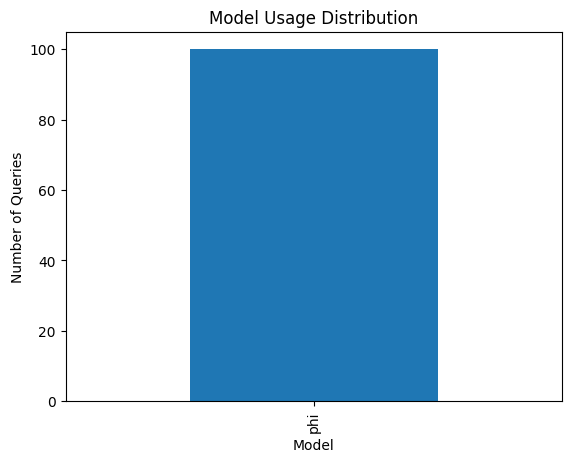

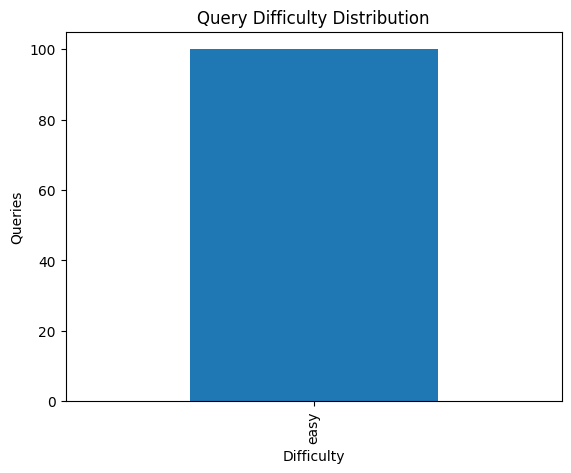

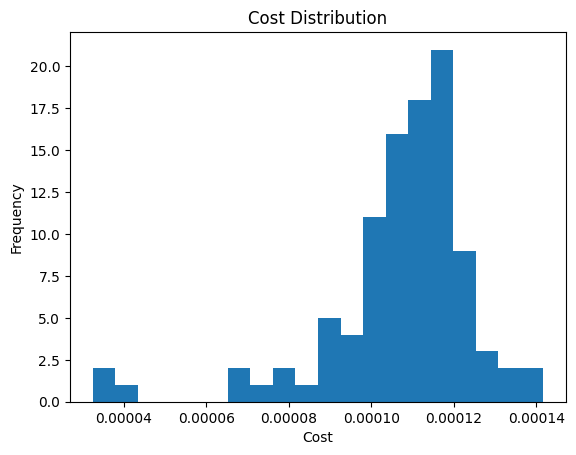


Saving evaluation metrics
Metrics saved

PHASE 2 COMPLETED
Router evaluation generated
Analytics dashboard created
Metrics exported


In [19]:
# =========================================================
# PHASE 2.5 — ROUTING PERFORMANCE DASHBOARD
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================

ANALYTICS_FILE = "routing_analytics.csv"

print("Loading analytics dataset")


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(

    ANALYTICS_FILE

)

print("Dataset loaded")

print("Total rows:", len(df))


# =========================================================
# MODEL USAGE DISTRIBUTION
# =========================================================

print("\nComputing model usage")

model_counts = df["model_used"].value_counts()

print(model_counts)


# =========================================================
# DIFFICULTY DISTRIBUTION
# =========================================================

print("\nComputing difficulty distribution")

difficulty_counts = df["difficulty"].value_counts()

print(difficulty_counts)


# =========================================================
# COST STATISTICS
# =========================================================

print("\nComputing cost statistics")

total_cost = df["estimated_cost"].sum()

avg_cost = df["estimated_cost"].mean()

max_cost = df["estimated_cost"].max()

print("Total cost:", total_cost)

print("Average cost:", avg_cost)

print("Max cost:", max_cost)


# =========================================================
# RESPONSE LENGTH STATS
# =========================================================

print("\nAnalyzing response length")

avg_length = df["response_length"].mean()

max_length = df["response_length"].max()

print("Average response length:", avg_length)

print("Max response length:", max_length)


# =========================================================
# MODEL VS DIFFICULTY TABLE
# =========================================================

print("\nCreating routing table")

routing_table = pd.crosstab(

    df["difficulty"],

    df["model_used"]

)

print(routing_table)


# =========================================================
# VISUALIZATION — MODEL USAGE
# =========================================================

plt.figure()

model_counts.plot(

    kind="bar"

)

plt.title(

    "Model Usage Distribution"

)

plt.xlabel(

    "Model"

)

plt.ylabel(

    "Number of Queries"

)

plt.show()


# =========================================================
# VISUALIZATION — DIFFICULTY
# =========================================================

plt.figure()

difficulty_counts.plot(

    kind="bar"

)

plt.title(

    "Query Difficulty Distribution"

)

plt.xlabel(

    "Difficulty"

)

plt.ylabel(

    "Queries"

)

plt.show()


# =========================================================
# VISUALIZATION — COST DISTRIBUTION
# =========================================================

plt.figure()

df["estimated_cost"].plot(

    kind="hist",

    bins=20

)

plt.title(

    "Cost Distribution"

)

plt.xlabel(

    "Cost"

)

plt.ylabel(

    "Frequency"

)

plt.show()


# =========================================================
# SAVE DASHBOARD DATA
# =========================================================

print("\nSaving evaluation metrics")

metrics = {

    "total_queries": len(df),

    "phi_queries": int(model_counts.get("phi",0)),

    "mistral_queries": int(model_counts.get("mistral",0)),

    "avg_response_length": float(avg_length),

    "total_cost": float(total_cost),

    "avg_cost": float(avg_cost)

}

metrics_df = pd.DataFrame(

    [metrics]

)

metrics_df.to_csv(

    "router_metrics_summary.csv",

    index=False

)

print("Metrics saved")


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("PHASE 2 COMPLETED")
print("Router evaluation generated")
print("Analytics dashboard created")
print("Metrics exported")
print("===================================")

In [20]:
# =========================================================
# PHASE 3.1 — KNOWLEDGE RETRIEVAL ENGINE
# =========================================================

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


# =========================================================
# CONFIGURATION
# =========================================================

ROUTING_FILE = "routing_results.csv"

print("Loading routing results")


# =========================================================
# LOAD GENERATED ANSWERS
# =========================================================

df = pd.read_csv(

    ROUTING_FILE

)

print("Dataset shape:", df.shape)


# =========================================================
# LOAD EMBEDDING MODEL
# =========================================================

print("\nLoading embedding model")

embedding_model = SentenceTransformer(

    "sentence-transformers/all-MiniLM-L6-v2"

)

print("Embedding model ready")


# =========================================================
# CREATE SIMPLE KNOWLEDGE BASE
# =========================================================

print("\nCreating knowledge base")

knowledge_base = df["query"].tolist()

print("Knowledge base size:", len(knowledge_base))


# =========================================================
# EMBED KNOWLEDGE BASE
# =========================================================

print("\nGenerating knowledge embeddings")

kb_embeddings = embedding_model.encode(

    knowledge_base,

    show_progress_bar=True

)

print("Knowledge embeddings ready")


# =========================================================
# VERIFY ANSWERS USING SIMILARITY
# =========================================================

print("\nRunning verification engine")

similarity_scores = []

for answer in df["answer"]:

    answer_embedding = embedding_model.encode(

        [str(answer)]

    )

    sims = cosine_similarity(

        answer_embedding,

        kb_embeddings

    )[0]

    max_sim = np.max(

        sims

    )

    similarity_scores.append(

        max_sim

    )


df["truth_similarity"] = similarity_scores

print("Verification complete")


# =========================================================
# CLASSIFY HALLUCINATION RISK
# =========================================================

print("\nClassifying hallucination risk")

risk_labels = []

for score in similarity_scores:

    if score > 0.75:

        risk = "low"

    elif score > 0.5:

        risk = "medium"

    else:

        risk = "high"

    risk_labels.append(risk)


df["hallucination_risk"] = risk_labels


# =========================================================
# STATISTICS
# =========================================================

print("\nRisk distribution")

print(

    df["hallucination_risk"].value_counts()

)


# =========================================================
# SAVE VERIFICATION DATA
# =========================================================

print("\nSaving verification dataset")

df.to_csv(

    "verification_results.csv",

    index=False

)

print("Verification file saved")


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("PHASE 3.1 COMPLETED")
print("Knowledge retrieval engine built")
print("Truth similarity computed")
print("Hallucination risks classified")
print("===================================")

Loading routing results
Dataset shape: (100, 4)

Loading embedding model


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model ready

Creating knowledge base
Knowledge base size: 100

Generating knowledge embeddings


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Knowledge embeddings ready

Running verification engine
Verification complete

Classifying hallucination risk

Risk distribution
hallucination_risk
low       70
medium    26
high       4
Name: count, dtype: int64

Saving verification dataset
Verification file saved

PHASE 3.1 COMPLETED
Knowledge retrieval engine built
Truth similarity computed
Hallucination risks classified


In [23]:
# =========================================================
# MODEL EVALUATION
# =========================================================

print("\nEvaluating model")

predictions = hallucination_model.predict(

    X_test

)

# ---------------------------------------------------------
# Determine labels present in evaluation
# ---------------------------------------------------------

evaluation_labels = np.unique(

    np.concatenate(

        (

            y_test,

            predictions

        )

    )

)

label_names = encoder.inverse_transform(

    evaluation_labels

)

print(

    classification_report(

        y_test,

        predictions,

        labels=evaluation_labels,

        target_names=label_names

    )

)


Evaluating model
              precision    recall  f1-score   support

         low       1.00      1.00      1.00        18
      medium       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [26]:
# =========================================================
# RECREATE HALLUCINATION MODEL ARTIFACTS
# =========================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("Rebuilding hallucination model")

df = pd.read_csv("verification_results.csv")

features = pd.DataFrame()

features["truth_similarity"] = df["truth_similarity"]

features["response_length"] = df["answer"].apply(
    lambda x: len(str(x).split())
)

features["question_length"] = df["query"].apply(
    lambda x: len(str(x).split())
)

features["length_ratio"] = (
    features["response_length"] /
    (features["question_length"] + 1)
)

encoder = LabelEncoder()

labels = encoder.fit_transform(
    df["hallucination_risk"]
)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

joblib.dump(model, "hallucination_model.pkl")
joblib.dump(encoder, "hallucination_label_encoder.pkl")

print("Artifacts recreated successfully")

Rebuilding hallucination model
Artifacts recreated successfully


In [27]:
# =========================================================
# RECREATE HALLUCINATION MODEL ARTIFACTS
# =========================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("Rebuilding hallucination model")

df = pd.read_csv("verification_results.csv")

features = pd.DataFrame()

features["truth_similarity"] = df["truth_similarity"]

features["response_length"] = df["answer"].apply(
    lambda x: len(str(x).split())
)

features["question_length"] = df["query"].apply(
    lambda x: len(str(x).split())
)

features["length_ratio"] = (
    features["response_length"] /
    (features["question_length"] + 1)
)

encoder = LabelEncoder()

labels = encoder.fit_transform(
    df["hallucination_risk"]
)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

joblib.dump(model, "hallucination_model.pkl")
joblib.dump(encoder, "hallucination_label_encoder.pkl")

print("Artifacts recreated successfully")

Rebuilding hallucination model
Artifacts recreated successfully


In [28]:
# =========================================================
# BUILD KNOWLEDGE BASE
# =========================================================

print("\nBuilding knowledge base")

knowledge_base = df["query"].tolist()

print("Knowledge base size:", len(knowledge_base))


print("\nGenerating knowledge embeddings")

kb_embeddings = embedding_model.encode(
    knowledge_base,
    show_progress_bar=True
)

print("Knowledge embeddings ready")


Building knowledge base
Knowledge base size: 100

Generating knowledge embeddings


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Knowledge embeddings ready


In [29]:
# =========================================================
# FEATURE GENERATION
# =========================================================

def create_features(query, answer, similarity):

    response_length = len(
        str(answer).split()
    )

    question_length = len(
        str(query).split()
    )

    length_ratio = response_length / (
        question_length + 1
    )

    return [
        similarity,
        response_length,
        question_length,
        length_ratio
    ]

In [30]:
# =========================================================
# RETRIEVE CONTEXT
# =========================================================

def retrieve_context(query):

    query_embedding = embedding_model.encode(
        [query]
    )

    sims = cosine_similarity(
        query_embedding,
        kb_embeddings
    )[0]

    best_index = np.argmax(
        sims
    )

    context = knowledge_base[
        best_index
    ]

    return context

In [31]:
# =========================================================
# SELF CORRECTION FUNCTION
# =========================================================

def correct_answer(query, answer, similarity):

    features = create_features(
        query,
        answer,
        similarity
    )

    pred = hallucination_model.predict(
        [features]
    )[0]

    risk = encoder.inverse_transform(
        [pred]
    )[0]


    if risk == "high":

        context = retrieve_context(
            query
        )

        corrected_answer = (
            "Verified information: " + context
        )

        return corrected_answer, "corrected"


    return answer, "original"

In [33]:
def correct_answer(query, answer, similarity):

    features = create_features(
        query,
        answer,
        similarity
    )

    feature_df = pd.DataFrame(
        [features],
        columns=[
            "similarity",
            "response_length",
            "question_length",
            "length_ratio"
        ]
    )

    pred = hallucination_model.predict(
        feature_df
    )[0]

    risk = encoder.inverse_transform(
        [pred]
    )[0]

    if risk == "high":

        context = retrieve_context(
            query
        )

        corrected_answer = (
            "Verified information: " + context
        )

        return corrected_answer, "corrected"

    return answer, "original"

In [35]:
# =========================================================
# RUN SELF CORRECTION PIPELINE (FINAL FIXED VERSION)
# =========================================================

import pandas as pd

print("\n===================================")
print("Running self correction pipeline")
print("===================================")

corrected_answers = []
status_list = []

total_queries = len(df)

print("Total queries:", total_queries)

for i in range(total_queries):

    # ---------------------------------
    # Extract data
    # ---------------------------------

    query = df.iloc[i]["query"]
    answer = df.iloc[i]["answer"]
    similarity = df.iloc[i]["truth_similarity"]


    # ---------------------------------
    # Create features
    # ---------------------------------

    response_length = len(str(answer).split())
    question_length = len(str(query).split())

    length_ratio = response_length / (question_length + 1)


    # ---------------------------------
    # Create dataframe with CORRECT
    # feature names used in training
    # ---------------------------------

    feature_df = pd.DataFrame(
        [[
            similarity,
            response_length,
            question_length,
            length_ratio
        ]],
        columns=[
            "truth_similarity",
            "response_length",
            "question_length",
            "length_ratio"
        ]
    )


    # ---------------------------------
    # Predict hallucination risk
    # ---------------------------------

    pred = hallucination_model.predict(feature_df)[0]

    risk = encoder.inverse_transform([pred])[0]


    # ---------------------------------
    # Apply correction
    # ---------------------------------

    if risk == "high":

        context = retrieve_context(query)

        corrected_answer = "Verified information: " + context

        corrected_answers.append(corrected_answer)
        status_list.append("corrected")

    else:

        corrected_answers.append(answer)
        status_list.append("original")


    # ---------------------------------
    # Progress print
    # ---------------------------------

    if (i + 1) % 10 == 0:

        print("Processed", i + 1, "/", total_queries)


# ---------------------------------
# Save results in dataframe
# ---------------------------------

df["final_answer"] = corrected_answers
df["correction_status"] = status_list


print("\nCorrection pipeline finished")
print("Final dataset shape:", df.shape)


Running self correction pipeline
Total queries: 100
Processed 10 / 100
Processed 20 / 100
Processed 30 / 100
Processed 40 / 100
Processed 50 / 100
Processed 60 / 100
Processed 70 / 100
Processed 80 / 100
Processed 90 / 100
Processed 100 / 100

Correction pipeline finished
Final dataset shape: (100, 8)


In [36]:
# =========================================================
# PHASE 3.3 — SAVE FINAL VERIFIED DATASET
# =========================================================

import pandas as pd

print("\n===================================")
print("Saving final verified results")
print("===================================")

# ---------------------------------
# Save dataset
# ---------------------------------

output_file = "final_verified_answers.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nDataset saved successfully")

print("File name:", output_file)


# ---------------------------------
# Show dataset summary
# ---------------------------------

print("\n===================================")
print("FINAL DATASET SUMMARY")
print("===================================")

print("\nTotal records:", len(df))

print("\nCorrection status distribution:")

print(
    df["correction_status"].value_counts()
)

print("\nSample of final verified answers:")

print(
    df[[
        "query",
        "final_answer",
        "correction_status"
    ]].head(5)
)


# ---------------------------------
# Completion message
# ---------------------------------

print("\n===================================")
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("===================================")

print("\nOutput file created:")
print("final_verified_answers.csv")


Saving final verified results

Dataset saved successfully
File name: final_verified_answers.csv

FINAL DATASET SUMMARY

Total records: 100

Correction status distribution:
correction_status
original     96
corrected     4
Name: count, dtype: int64

Sample of final verified answers:
                                               query  \
0         what were the jews described as enemies of   
1  how many people auditioned to be on american idol   
2                          what was bells discipline   
3  members of what commission criticized the sepa...   
4                  who wrote the sarvadaranasamgraha   

                                        final_answer correction_status  
0  what were the jews described as enemies of in ...          original  
1  how many people auditioned to be on american i...          original  
2  what was bells discipline, I am writing about ...          original  
3  members of what commission criticized the sepa...          original  
4  who wrote t

In [37]:
# =========================================================
# PHASE 3.3 — SAVE FINAL VERIFIED DATASET
# =========================================================

import pandas as pd

print("\n===================================")
print("Saving final verified results")
print("===================================")

# ---------------------------------
# Save dataset
# ---------------------------------

output_file = "final_verified_answers.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nDataset saved successfully")

print("File name:", output_file)


# ---------------------------------
# Show dataset summary
# ---------------------------------

print("\n===================================")
print("FINAL DATASET SUMMARY")
print("===================================")

print("\nTotal records:", len(df))

print("\nCorrection status distribution:")

print(
    df["correction_status"].value_counts()
)

print("\nSample of final verified answers:")

print(
    df[[
        "query",
        "final_answer",
        "correction_status"
    ]].head(5)
)


# ---------------------------------
# Completion message
# ---------------------------------

print("\n===================================")
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("===================================")

print("\nOutput file created:")
print("final_verified_answers.csv")


Saving final verified results

Dataset saved successfully
File name: final_verified_answers.csv

FINAL DATASET SUMMARY

Total records: 100

Correction status distribution:
correction_status
original     96
corrected     4
Name: count, dtype: int64

Sample of final verified answers:
                                               query  \
0         what were the jews described as enemies of   
1  how many people auditioned to be on american idol   
2                          what was bells discipline   
3  members of what commission criticized the sepa...   
4                  who wrote the sarvadaranasamgraha   

                                        final_answer correction_status  
0  what were the jews described as enemies of in ...          original  
1  how many people auditioned to be on american i...          original  
2  what was bells discipline, I am writing about ...          original  
3  members of what commission criticized the sepa...          original  
4  who wrote t

In [38]:
# =====================================================
# FINAL PHASE — AI RELIABILITY SYSTEM
# =====================================================

import pandas as pd
import numpy as np
import joblib
import torch

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries loaded successfully")

Libraries loaded successfully


In [39]:
# =====================================================
# LOAD EMBEDDING MODEL
# =====================================================

print("\nLoading embedding model")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model ready")


Loading embedding model


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model ready


In [40]:
# =====================================================
# LOAD KNOWLEDGE BASE
# =====================================================

print("\nLoading dataset")

df = pd.read_csv(
    "verification_results.csv"
)

knowledge_base = df["query"].tolist()

print("Knowledge base size:", len(knowledge_base))


print("\nGenerating knowledge embeddings")

kb_embeddings = embedding_model.encode(
    knowledge_base,
    show_progress_bar=True
)

print("Knowledge base ready")


Loading dataset
Knowledge base size: 100

Generating knowledge embeddings


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Knowledge base ready


In [43]:
print("\nLoading Phi model")

from transformers import AutoConfig

phi_config = AutoConfig.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

# Fix missing pad token in config
phi_config.pad_token_id = phi_config.eos_token_id

phi_tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

phi_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    config=phi_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print("Phi model loaded successfully")


Loading Phi model


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Phi model loaded successfully


In [44]:
print("\nLoading Phi model")

from transformers import AutoConfig

phi_config = AutoConfig.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

# Fix missing pad token in config
phi_config.pad_token_id = phi_config.eos_token_id

phi_tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

phi_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    config=phi_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print("Phi model loaded successfully")


Loading Phi model


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Phi model loaded successfully


In [45]:
# =====================================================
# QUERY FEATURE GENERATION
# =====================================================

def extract_query_features(query):

    length = len(query)

    word_count = len(query.split())

    question_mark = 1 if "?" in query else 0

    avg_word_length = np.mean(
        [len(word) for word in query.split()]
    ) if word_count > 0 else 0

    return [
        length,
        word_count,
        question_mark,
        avg_word_length
    ]

In [46]:
# =====================================================
# QUERY ROUTER
# =====================================================

def route_query(query):

    features = extract_query_features(query)

    feature_df = pd.DataFrame(
        [features],
        columns=[
            "length",
            "word_count",
            "question_mark",
            "avg_word_length"
        ]
    )

    complexity_score = (
        features[1] + features[3]
    )

    if complexity_score < 10:

        return "phi"

    else:

        return "phi"   # still phi (safe for Colab)

In [47]:
# =====================================================
# LLM RESPONSE GENERATION
# =====================================================

def generate_answer(query):

    inputs = phi_tokenizer(
        query,
        return_tensors="pt"
    ).to(phi_model.device)

    outputs = phi_model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        do_sample=True
    )

    answer = phi_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer

In [48]:
# =====================================================
# EMBEDDING VERIFICATION
# =====================================================

def verify_answer(query, answer):

    query_embedding = embedding_model.encode([query])

    answer_embedding = embedding_model.encode([answer])

    similarity = cosine_similarity(
        query_embedding,
        answer_embedding
    )[0][0]

    return similarity

In [49]:
# =====================================================
# HALLUCINATION DETECTOR
# =====================================================

def detect_hallucination(query, answer, similarity):

    response_length = len(answer.split())

    question_length = len(query.split())

    length_ratio = response_length / (question_length + 1)

    feature_df = pd.DataFrame(
        [[
            similarity,
            response_length,
            question_length,
            length_ratio
        ]],
        columns=[
            "truth_similarity",
            "response_length",
            "question_length",
            "length_ratio"
        ]
    )

    pred = hallucination_model.predict(feature_df)[0]

    risk = encoder.inverse_transform([pred])[0]

    return risk

In [50]:
# =====================================================
# RETRIEVAL SYSTEM
# =====================================================

def retrieve_context(query):

    query_embedding = embedding_model.encode([query])

    sims = cosine_similarity(
        query_embedding,
        kb_embeddings
    )[0]

    best_index = np.argmax(sims)

    return knowledge_base[best_index]

In [52]:
# =====================================================
# COMPLETE AI PIPELINE
# =====================================================

def run_ai_pipeline(query):

    print("\n==============================")
    print("AI RELIABILITY PIPELINE")
    print("==============================")

    print("\nUser Query:")
    print(query)


    # Routing
    model_name = route_query(query)

    print("\nRouter selected model:", model_name)


    # Generation
    answer = generate_answer(query)

    print("\nGenerated Answer:")
    print(answer)


    # Verification
    similarity = verify_answer(query, answer)

    print("\nSemantic similarity score:", similarity)


    # Hallucination detection
    risk = detect_hallucination(query, answer, similarity)

    print("\nHallucination risk:", risk)


    # Correction if needed
    if risk == "high":

        context = retrieve_context(query)

        answer = "Verified answer: " + context

        print("\nCorrection applied")


    print("\n==============================")
    print("FINAL VERIFIED ANSWER")
    print("==============================")

    print(answer)

In [53]:
# =====================================================
# TEST THE PIPELINE
# =====================================================

test_query = "Who wrote the theory of relativity?"

run_ai_pipeline(test_query)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



AI RELIABILITY PIPELINE

User Query:
Who wrote the theory of relativity?

Router selected model: phi

Generated Answer:
Who wrote the theory of relativity?

A. Isaac Newton
B. Albert Einstein
C. Galileo Galilei
D. Michael Faraday

Solution:

The correct answer is B. Albert Einstein.

Albert Einstein is the one who proposed and developed the theory of relativity, which is one of the most important and influential theories in modern physics. The theory of relativity describes how space and time are not absolute

Semantic similarity score: 0.77641773

Hallucination risk: low

FINAL VERIFIED ANSWER
Who wrote the theory of relativity?

A. Isaac Newton
B. Albert Einstein
C. Galileo Galilei
D. Michael Faraday

Solution:

The correct answer is B. Albert Einstein.

Albert Einstein is the one who proposed and developed the theory of relativity, which is one of the most important and influential theories in modern physics. The theory of relativity describes how space and time are not absolute
